<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/36_Machine_Learning_with_Tree-Based_Models_in_Python/01_Classification_and_Regression_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt
# Import confusion matrix and train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Grains/seeds-width-vs-length.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
grains = pd.read_csv(url, header=None)
display(grains.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/34_Unsupervised_Learning_in_Python/dataset/Grains/varieties.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
varieties = pd.read_csv(url)
display(varieties.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/food_preservation.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
food_preservation = pd.read_csv(url)
display(food_preservation.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/toy_durability.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
toy_durability = pd.read_csv(url)
display(toy_durability.head())

,0,1
0,3.312,5.763
1,3.333,5.554
2,3.337,5.291
3,3.379,5.324
4,3.562,5.658


,varieties
0,Kama wheat
1,Kama wheat
2,Kama wheat
3,Kama wheat
4,Kama wheat


,ProductID,PreservationMethod,FoodType,NutrientRetention,ShelfLife
0,1,Drying,Fruit,59.17,184.04
1,2,Freezing,Meat,72.29,104.46
2,3,Drying,Fruit,80.06,75.03
3,4,Canning,Fruit,98.50,103.34
4,5,Canning,Vegetable,59.09,97.46


,Toy_Type,Durability_Score
0,Recreational,67.2
1,Recreational,80.9
2,Recreational,69.7
3,Recreational,82.7
4,Educational,79.6


  **Train your first classification tree**  
In this exercise you'll work with the Wisconsin Breast Cancer Dataset from the UCI machine learning repository. You'll predict whether a tumor is malignant or benign based on two features: the mean radius of the tumor (radius_mean) and its mean number of concave points (concave points_mean).

The dataset is already loaded in your workspace and is split into 80% train and 20% test. The feature matrices are assigned to X_train and X_test, while the arrays of labels are assigned to y_train and y_test where class 1 corresponds to a malignant tumor and class 0 corresponds to a benign tumor. To obtain reproducible results, we also defined a variable called SEED which is set to 1.

In [10]:
# Import DecisionTreeClassifier from sklearn.tree
from sklearn.tree import DecisionTreeClassifier

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/36_Machine_Learning_with_Tree-Based_Models_in_Python/dataset/wbc.csv"
# Read the CSV file, skipping the header row and excluding the 'id' column (column 0)
wbc = pd.read_csv(url)
display(wbc.head())

# Features are columns 2 and 3 (radius_mean and texture_mean)
X = wbc.iloc[:, 2:4]
# Labels are in column 1 (diagnosis)
y = wbc.iloc[:, 1]

# Define the SEED for reproducible results
SEED = 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Instantiate a DecisionTreeClassifier 'dt' with a maximum depth of 6
dt = DecisionTreeClassifier(max_depth=6, random_state=SEED)

# Fit dt to the training set
dt.fit(X_train, y_train)

# Predict test set labels
y_pred = dt.predict(X_test)
print(y_pred[0:5])

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


['M' 'B' 'B' 'M' 'B']


**Evaluate the classification tree**  
Now that you've fit your first classification tree, it's time to evaluate its performance on the test set. You'll do so using the accuracy metric which corresponds to the fraction of correct predictions made on the test set.

The trained model dt from the previous exercise is loaded in your workspace along with the test set features matrix X_test and the array of labels y_test

In [11]:
# Import accuracy_score
from sklearn.metrics import accuracy_score

# Predict test set labels
y_pred = dt.predict(X_test)

# Compute test set accuracy
acc = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(acc))

# Using only two features, your tree was able to achieve an accuracy of 89%!

Test set accuracy: 0.89


**Logistic regression vs classification tree**  
A classification tree divides the feature space into rectangular regions. In contrast, a linear model such as logistic regression produces only a single linear decision boundary dividing the feature space into two decision regions.

We have written a custom function called plot_labeled_decision_regions() that you can use to plot the decision regions of a list containing two trained classifiers. You can type help(plot_labeled_decision_regions) in the shell to learn more about this function.

X_train, X_test, y_train, y_test, the model dt that you've trained in an earlier exercise, as well as the function `plot_labeled_decision_regions`() are available in your workspace.

Function For plotting Outside the scope of this course Try Yourself To understand

In [12]:
def plot_decision_regions(X, y, clf,
                              feature_index=None,
                              filler_feature_values=None,
                              filler_feature_ranges=None,
                              ax=None,
                              X_highlight=None,
                              zoom_factor=1.,
                              legend=1,
                              hide_spines=True,
                              markers='s^oxv<>',
                              colors=('#1f77b4,#ff7f0e,#3ca02c,#d62728,'
                                      '#9467bd,#8c564b,#e377c2,'
                                      '#7f7f7f,#bcbd22,#17becf'),
                              scatter_kwargs=None,
                              contourf_kwargs=None,
                              scatter_highlight_kwargs=None):
        """Plot decision regions of a classifier.

        Please note that this functions assumes that class labels are
        labeled consecutively, e.g,. 0, 1, 2, 3, 4, and 5. If you have class
        labels with integer labels > 4, you may want to provide additional colors
        and/or markers as `colors` and `markers` arguments.
        See http://matplotlib.org/examples/color/named_colors.html for more
        information.

        Parameters
        ----------
        X : array-like, shape = [n_samples, n_features]
            Feature Matrix.

        y : array-like, shape = [n_samples]
            True class labels.

        clf : Classifier object.
            Must have a .predict method.

        feature_index : array-like (default: (0,) for 1D, (0, 1) otherwise)
            Feature indices to use for plotting. The first index in
            `feature_index` will be on the x-axis, the second index will be
            on the y-axis.

        filler_feature_values : dict (default: None)
            Only needed for number features > 2. Dictionary of feature
            index-value pairs for the features not being plotted.

        filler_feature_ranges : dict (default: None)
            Only needed for number features > 2. Dictionary of feature
            index-value pairs for the features not being plotted. Will use the
            ranges provided to select training samples for plotting.

        ax : matplotlib.axes.Axes (default: None)
            An existing matplotlib Axes. Creates
            one if ax=None.

        X_highlight : array-like, shape = [n_samples, n_features] (default: None)
            An array with data points that are used to highlight samples in `X`.

        zoom_factor : float (default: 1.0)
            Controls the scale of the x- and y-axis of the decision plot.

        hide_spines : bool (default: True)
            Hide axis spines if True.

        legend : int (default: 1)
            Integer to specify the legend location.
            No legend if legend is 0.

        markers : str (default: 's^oxv<>')
            Scatterplot markers.

        colors : str (default: 'red,blue,limegreen,gray,cyan')
            Comma separated list of colors.

        scatter_kwargs : dict (default: None)
            Keyword arguments for underlying matplotlib scatter function.

        contourf_kwargs : dict (default: None)
            Keyword arguments for underlying matplotlib contourf function.

        scatter_highlight_kwargs : dict (default: None)
            Keyword arguments for underlying matplotlib scatter function.

        Returns
        ---------
        ax : matplotlib.axes.Axes object

        Examples
        -----------
        For usage examples, please see
        http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/

        """

        check_Xy(X, y, y_int=True)  # Validate X and y arrays
        dim = X.shape[1]

        if ax is None:
            ax = plt.gca()

        plot_testdata = True
        if not isinstance(X_highlight, np.ndarray):
            if X_highlight is not None:
                raise ValueError('X_highlight must be a NumPy array or None')
            else:
                plot_testdata = False
        elif len(X_highlight.shape) < 2:
            raise ValueError('X_highlight must be a 2D array')

        if feature_index is not None:
            # Unpack and validate the feature_index values
            if dim == 1:
                raise ValueError(
                    'feature_index requires more than one training feature')
            try:
                x_index, y_index = feature_index
            except ValueError:
                raise ValueError(
                    'Unable to unpack feature_index. Make sure feature_index '
                    'only has two dimensions.')
            try:
                X[:, x_index], X[:, y_index]
            except IndexError:
                raise IndexError(
                    'feature_index values out of range. X.shape is {}, but '
                    'feature_index is {}'.format(X.shape, feature_index))
        else:
            feature_index = (0, 1)
            x_index, y_index = feature_index

        # Extra input validation for higher number of training features
        if dim > 2:
            if filler_feature_values is None:
                raise ValueError('Filler values must be provided when '
                                 'X has more than 2 training features.')

            if filler_feature_ranges is not None:
                if not set(filler_feature_values) == set(filler_feature_ranges):
                    raise ValueError(
                        'filler_feature_values and filler_feature_ranges must '
                        'have the same keys')

            # Check that all columns in X are accounted for
            column_check = np.zeros(dim, dtype=bool)
            for idx in filler_feature_values:
                column_check[idx] = True
            for idx in feature_index:
                column_check[idx] = True
            if not all(column_check):
                missing_cols = np.argwhere(~column_check).flatten()
                raise ValueError(
                    'Column(s) {} need to be accounted for in either '
                    'feature_index or filler_feature_values'.format(missing_cols))

        marker_gen = cycle(list(markers))

        n_classes = np.unique(y).shape[0]
        colors = colors.split(',')
        colors_gen = cycle(colors)
        colors = [next(colors_gen) for c in range(n_classes)]

        # Get minimum and maximum
        x_min, x_max = (X[:, x_index].min() - 1./zoom_factor,
                        X[:, x_index].max() + 1./zoom_factor)
        if dim == 1:
            y_min, y_max = -1, 1
        else:
            y_min, y_max = (X[:, y_index].min() - 1./zoom_factor,
                            X[:, y_index].max() + 1./zoom_factor)

        xnum, ynum = plt.gcf().dpi * plt.gcf().get_size_inches()
        xnum, ynum = floor(xnum), ceil(ynum)
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, num=xnum),
                             np.linspace(y_min, y_max, num=ynum))

        if dim == 1:
            X_predict = np.array([xx.ravel()]).T
        else:
            X_grid = np.array([xx.ravel(), yy.ravel()]).T
            X_predict = np.zeros((X_grid.shape[0], dim))
            X_predict[:, x_index] = X_grid[:, 0]
            X_predict[:, y_index] = X_grid[:, 1]
            if dim > 2:
                for feature_idx in filler_feature_values:
                    X_predict[:, feature_idx] = filler_feature_values[feature_idx]
        Z = clf.predict(X_predict.astype(X.dtype))
        Z = Z.reshape(xx.shape)
        # Plot decisoin region
        # Make sure contourf_kwargs has backwards compatible defaults
        contourf_kwargs_default = {'alpha': 0.45, 'antialiased': True}
        contourf_kwargs = format_kwarg_dictionaries(
                            default_kwargs=contourf_kwargs_default,
                            user_kwargs=contourf_kwargs,
                            protected_keys=['colors', 'levels'])
        cset = ax.contourf(xx, yy, Z,
                           colors=colors,
                           levels=np.arange(Z.max() + 2) - 0.5,
                           **contourf_kwargs)

        ax.contour(xx, yy, Z, cset.levels,
                   colors='k',
                   linewidths=0.5,
                   antialiased=True)

        ax.axis([xx.min(), xx.max(), yy.min(), yy.max()])

        # Scatter training data samples
        # Make sure scatter_kwargs has backwards compatible defaults
        scatter_kwargs_default = {'alpha': 0.8, 'edgecolor': 'black'}
        scatter_kwargs = format_kwarg_dictionaries(
                            default_kwargs=scatter_kwargs_default,
                            user_kwargs=scatter_kwargs,
                            protected_keys=['c', 'marker', 'label'])
        for idx, c in enumerate(np.unique(y)):
            if dim == 1:
                y_data = [0 for i in X[y == c]]
                x_data = X[y == c]
            elif dim == 2:
                y_data = X[y == c, y_index]
                x_data = X[y == c, x_index]
            elif dim > 2 and filler_feature_ranges is not None:
                class_mask = y == c
                feature_range_mask = get_feature_range_mask(
                                X, filler_feature_values=filler_feature_values,
                                filler_feature_ranges=filler_feature_ranges)
                y_data = X[class_mask & feature_range_mask, y_index]
                x_data = X[class_mask & feature_range_mask, x_index]
            else:
                continue

            ax.scatter(x=x_data,
                       y=y_data,
                       c=colors[idx],
                       marker=next(marker_gen),
                       label=c,
                       **scatter_kwargs)

        if hide_spines:
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
        ax.yaxis.set_ticks_position('left')
        ax.xaxis.set_ticks_position('bottom')
        if dim == 1:
            ax.axes.get_yaxis().set_ticks([])

        if plot_testdata:
            if dim == 1:
                x_data = X_highlight
                y_data = [0 for i in X_highlight]
            elif dim == 2:
                x_data = X_highlight[:, x_index]
                y_data = X_highlight[:, y_index]
            else:
                feature_range_mask = get_feature_range_mask(
                        X_highlight, filler_feature_values=filler_feature_values,
                        filler_feature_ranges=filler_feature_ranges)
                y_data = X_highlight[feature_range_mask, y_index]
                x_data = X_highlight[feature_range_mask, x_index]

            # Make sure scatter_highlight_kwargs backwards compatible defaults
            scatter_highlight_defaults = {'c': 'none',
                                          'edgecolor': 'black',
                                          'alpha': 1.0,
                                          'linewidths': 1,
                                          'marker': 'o',
                                          's': 80}
            scatter_highlight_kwargs = format_kwarg_dictionaries(
                                        default_kwargs=scatter_highlight_defaults,
                                        user_kwargs=scatter_highlight_kwargs)
            ax.scatter(x_data,
                       y_data,
                       **scatter_highlight_kwargs)

        if legend:
            if dim > 2 and filler_feature_ranges is None:
                pass
            else:
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(handles, labels,
                          framealpha=0.3, scatterpoints=1, loc=legend)

        return ax

In [16]:
from itertools import cycle, islice
from math import ceil, floor
from sklearn.preprocessing import LabelEncoder
from mlxtend.utils import format_kwarg_dictionaries

def plot_labeled_decision_regions(X, y, models):
    """
    Plots the decision regions of a list of classifiers.

    Parameters
    ----------
    X : array-like, shape = [n_samples, n_features]
        Feature Matrix.

    y : array-like, shape = [n_samples]
        True class labels.

    models : list
        A list of classifier objects. Each classifier must have a .predict method.

    """
    if len(models) < 2:
        raise ValueError("Please provide at least two classifiers in the list.")

    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))

    # Convert y to numeric if it's not already
    if not pd.api.types.is_numeric_dtype(y):
        le = LabelEncoder()
        y_plot = le.fit_transform(y)
    else:
        y_plot = y.values if isinstance(y, pd.Series) else y

    X_plot = X.values if isinstance(X, pd.DataFrame) else X

    for i, model in enumerate(models):
        # Fit the model with the numerically encoded labels before plotting
        model.fit(X_plot, y_plot)
        plot_decision_regions(X_plot, y_plot, model, legend= 2, ax = axes[i])
        axes[i].set_title(f'{type(model).__name__} Decision Regions') # More descriptive title
        axes[i].set_xlabel('radius_mean') # Explicitly set x-axis label
        axes[i].set_ylabel('texture_mean') # Explicitly set y-axis label

    plt.tight_layout()
    plt.show()

# Helper function (assuming mlxtend is installed and check_Xy is available)
def check_Xy(X, y, y_int=False):
    """Helper function to check X and y arrays."""
    if not isinstance(X, np.ndarray) or not isinstance(y, np.ndarray):
         raise TypeError("X and y must be NumPy arrays.")
    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y must have the same number of samples.")
    if y_int and not np.issubdtype(y.dtype, np.integer):
         raise ValueError("y must be of integer type.")

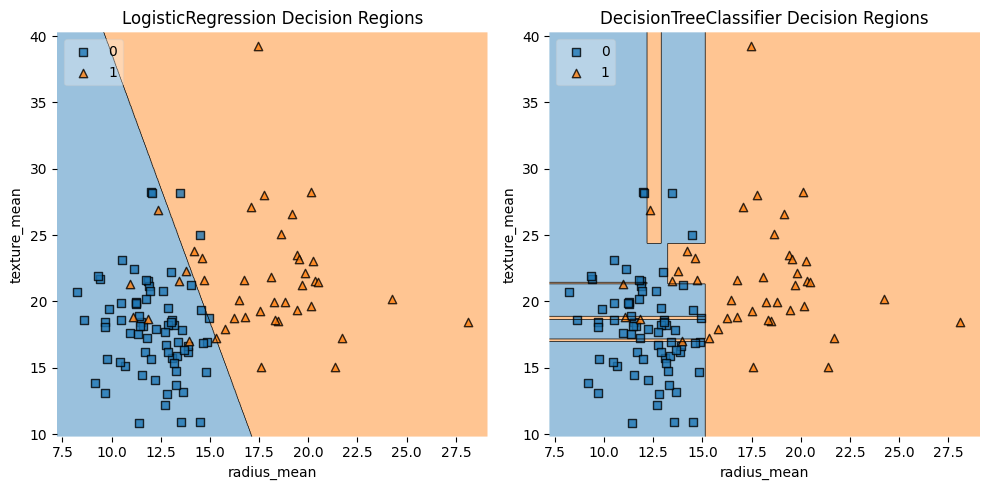

In [17]:
# Import LogisticRegression from sklearn.linear_model
from sklearn.linear_model import  LogisticRegression


# Instatiate logreg
logreg = LogisticRegression(random_state=1)

# Fit logreg to the training set
logreg.fit(X_train, y_train)

# Define a list called clfs containing the two classifiers logreg and dt
clfs = [logreg, dt]

# Review the decision regions of the two classifiers
plot_labeled_decision_regions(X_test, y_test, clfs)

# Notice how the decision boundary produced by logistic regression is linear while
# the boundaries produced by the classification tree divide the feature space into rectangular regions.

### Classification tree Learning

**Growing a classification tree**  
In the video, you saw that the growth of an unconstrained classification tree followed a few simple rules. Which of the following is not one of these rules?


- The existence of a node depends on the state of its predecessors.

- The impurity of a node can be determined using different criteria such as entropy and the gini-index.

- When the information gain resulting from splitting a node is null, the node is declared as a leaf.

- When an internal node is split, the split is performed in such a way so that information gain is minimized.

 *It's quite the contrary! Actually, splitting an internal node always involves maximizing information gain!*

**Using entropy as a criterion**  
In this exercise, you'll train a classification tree on the Wisconsin Breast Cancer dataset using entropy as an information criterion. You'll do so using all the 30 features in the dataset, which is split into 80% train and 20% test.

X_train as well as the array of labels y_train are available in your workspace.

In [19]:
# Import DecisionTreeClassifier from sklearn.tree
from sklearn.tree import DecisionTreeClassifier

# Instantiate dt_entropy, set 'entropy' as the information criterion
dt_entropy = DecisionTreeClassifier(max_depth=8, criterion='entropy', random_state=1)

# Fit dt_entropy to the training set
dt_entropy.fit(X_train, y_train)

# In the next exercise, you'll compare the accuracy of dt_entropy to the accuracy of a another tree trained using the gini-index as the information criterion.

DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=1)

**Entropy vs Gini index**  
In this exercise you'll compare the test set accuracy of dt_entropy to the accuracy of another tree named dt_gini. The tree dt_gini was trained on the same dataset using the same parameters except for the information criterion which was set to the gini index using the keyword '`gini`'.

X_test, y_test, dt_entropy, as well as accuracy_gini which corresponds to the test set accuracy achieved by `dt_gini` are available in your workspace.

In [21]:
# Import accuracy_score from sklearn.metrics
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Use dt_entropy to predict test set labels
y_pred_entropy = dt_entropy.predict(X_test)

# Evaluate accuracy_entropy
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

# Instantiate dt_gini, set 'gini' as the information criterion
dt_gini = DecisionTreeClassifier(max_depth=8, criterion='gini', random_state=1)

# Fit dt_gini to the training set
dt_gini.fit(X_train, y_train)

# Use dt_gini to predict test set labels
y_pred_gini = dt_gini.predict(X_test)

# Evaluate accuracy_gini
accuracy_gini = accuracy_score(y_test, y_pred_gini)

# Print accuracy_entropy
print(f'Accuracy achieved by using entropy: {accuracy_entropy:.3f}')

# Print accuracy_gini
print(f'Accuracy achieved by using the gini index: {accuracy_gini:.3f}')

# Notice how the two models achieve almost the same accuracy. Most of the time, the gini index and entropy lead to the same results.
#  The gini index is slightly faster to compute and is the default criterion used in the DecisionTreeClassifier model of scikit-learn.

Accuracy achieved by using entropy: 0.886
Accuracy achieved by using the gini index: 0.877


### Decision Tree for Regression

**Train your first regression tree**  
In this exercise, you'll train a regression tree to predict the mpg (miles per gallon) consumption of cars in the auto-mpg dataset using all the six available features.

The dataset is processed for you and is split to 80% train and 20% test. The features matrix X_train and the array y_train are available in your workspace.

In [28]:
# Import DecisionTreeRegressor from sklearn.tree
from sklearn.tree import DecisionTreeRegressor

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/36_Machine_Learning_with_Tree-Based_Models_in_Python/dataset/auto.csv"
# Read the CSV file, skipping the header row and excluding the 'id' column (column 0)
auto = pd.read_csv(url)
display(auto.head())

# Features are columns 2 and 3 (radius_mean and texture_mean)
X = auto.iloc[:,1:4]
# Labels are in column 1 (diagnosis)
y = auto.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# Instantiate dt
dt = DecisionTreeRegressor(max_depth=8,
             min_samples_leaf=0.13,
            random_state=3)

# Fit dt to the training set
dt.fit(X_train, y_train)

,mpg,displ,hp,weight,accel,origin,size
0,18.0,250.0,88,3139,14.5,US,15.0
1,9.0,304.0,193,4732,18.5,US,20.0
2,36.1,91.0,60,1800,16.4,Asia,10.0
3,18.5,250.0,98,3525,19.0,US,15.0
4,34.3,97.0,78,2188,15.8,Europe,10.0


DecisionTreeRegressor(max_depth=8, min_samples_leaf=0.13, random_state=3)

**Evaluate the regression tree**  
In this exercise, you will evaluate the test set performance of dt using the Root Mean Squared Error (RMSE) metric. The RMSE of a model measures, on average, how much the model's predictions differ from the actual labels. The RMSE of a model can be obtained by computing the square root of the model's Mean Squared Error (MSE).

The features matrix X_test, the array y_test, as well as the decision tree regressor dt that you trained in the previous exercise are available in your workspace.

In [29]:
# Import mean_squared_error from sklearn.metrics as MSE
from sklearn.metrics import mean_squared_error as MSE

# Compute y_pred
y_pred = dt.predict(X_test)

# Compute mse_dt
mse_dt = MSE(y_test, y_pred)

# Compute rmse_dt
rmse_dt = mse_dt ** (1/2)

# Print rmse_dt
print("Test set RMSE of dt: {:.2f}".format(rmse_dt))

# you'll compare the test-set RMSE of dt to that of a linear regression model trained on the same dataset.

Test set RMSE of dt: 4.37


**Linear regression vs regression tree**  
In this exercise, you'll compare the test set RMSE of dt to that achieved by a linear regression model. We have already instantiated a linear regression model lr and trained it on the same dataset as dt.

The features matrix X_test, the array of labels y_test, the trained linear regression model lr, mean_squared_error function which was imported under the alias MSE and rmse_dt from the previous exercise are available in your workspace.

In [31]:
# Import mean_squared_error from sklearn.metrics as MSE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.linear_model import LinearRegression

# Instantiate a Linear Regression model
lr = LinearRegression()

# Fit the model to the training data
lr.fit(X_train, y_train)

# Predict test set labels
y_pred_lr = lr.predict(X_test)

# Compute mse_lr
mse_lr = MSE(y_test, y_pred_lr)

# Compute rmse_lr
rmse_lr = mse_lr ** (1/2)

# Print rmse_lr
print('Linear Regression test set RMSE: {:.2f}'.format(rmse_lr))

# Print rmse_dt
print('Regression Tree test set RMSE: {:.2f}'.format(rmse_dt))

Linear Regression test set RMSE: 4.97
Regression Tree test set RMSE: 4.37
